# Connect Forest Management Model with Forest Carbon Budget Model (without calibration)

## Set up Modelling Environment

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios

In [2]:
def select_case_study(case_study):
    print(f"Selected scenario: {case_study}")
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='test',
    description='Case Study:'
)
display(case_study_dropdown)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')

Dropdown(description='Case Study:', index=3, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

In [24]:
def select_obj(obj_mode):
    print(f"Selected scenario: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='min_em',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Objective:', index=3, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='min_em')

In [25]:
#Start Calculating the Running Time
Start = time.time()

In [26]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
output_csv_path='./outputs/csv'
output_pdf_path='./outputs/pdf'

In [27]:
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1)

display(hwp_pool_effect)

FloatSlider(value=1.0, description='HWP_effect', max=1.0, step=1.0)

In [28]:
hwp_pool_effect_value = hwp_pool_effect.value

In [29]:
# Here we indicate whether the harvested pool products turn into emissions immediately instead of turning into wood products.
if hwp_pool_effect_value == 0:
    release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1)
    display(release_immediately)

In [30]:
if hwp_pool_effect_value == 0:
    release_immediately_value = release_immediately.value
else:  
    release_immediately_value = 0

In [31]:
if hwp_pool_effect_value != 0:
    displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1)
    display(displacement_effect)

FloatSlider(value=1.0, description='Displacement', max=1.0, step=1.0)

In [32]:
if hwp_pool_effect_value != 0:
    displacement_effect = displacement_effect.value
else:  
    displacement_effect = 0

In [33]:
if displacement_effect == 0:
   clt_percentage = 0
   credibility = 0
else:
    clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5)
    credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1)
    display(clt_percentage, credibility)

FloatSlider(value=0.5, description='CLT_percent:', max=1.0)

FloatSlider(value=1.0, description='Credibility:', max=1.0)

In [34]:
max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=0.1)
budget_input = widgets.FloatText(
    value=10000000,
    description='Budget:',
    disabled=False)
display(max_harvest, budget_input)

FloatSlider(value=0.1, description='Max_harvest:', max=1.0, step=0.05)

FloatText(value=10000000.0, description='Budget:')

In [35]:
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")
scenario_dropdown = widgets.Dropdown(
    options=['test', 'no_cons', 'bau_redchrs'],
    value='no_cons',
    description='Scenario:'
)
display(scenario_dropdown)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')

Dropdown(description='Scenario:', index=1, options=('test', 'no_cons', 'bau_redchrs'), value='no_cons')

In [36]:
if displacement_effect != 0:
    clt_percentage = clt_percentage.value
    credibility = credibility.value
max_harvest = max_harvest.value
budget_input = budget_input.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
case_study = case_study_dropdown.value

In [37]:
# Define case study mappings
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

# Retrieve model details based on case study
model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [38]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [39]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [40]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/redchris_c_curves_p.pkl
Loaded data from ./inputs/curves/redchris_c_curves_f.pkl


In [41]:
# Define Sum Carbon Pools and Sum Carbon Fluxes
biomass_pools = ['SoftwoodMerch','SoftwoodFoliage', 'SoftwoodOther', 'SoftwoodCoarseRoots','SoftwoodFineRoots',                        
                 'HardwoodMerch', 'HardwoodFoliage', 'HardwoodOther', 'HardwoodCoarseRoots', 'HardwoodFineRoots']
dom_pools = ['AboveGroundVeryFastSoil', 'BelowGroundVeryFastSoil', 'AboveGroundFastSoil', 'BelowGroundFastSoil',
             'MediumSoil', 'AboveGroundSlowSoil', 'BelowGroundSlowSoil', 'SoftwoodStemSnag', 'SoftwoodBranchSnag',
             'HardwoodStemSnag', 'HardwoodBranchSnag']
all_fluxes = [
    'DisturbanceCO2Production',
    'DisturbanceCH4Production',
    'DisturbanceCOProduction',
    'DisturbanceBioCO2Emission',
    'DisturbanceBioCH4Emission',
    'DisturbanceBioCOEmission',
    'DecayDOMCO2Emission',
    'DisturbanceSoftProduction',
    'DisturbanceHardProduction',
    'DisturbanceDOMProduction',
    'DeltaBiomass_AG',
    'DeltaBiomass_BG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput',
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir',
    'DisturbanceMerchToAir',
    'DisturbanceFolToAir',
    'DisturbanceOthToAir',
    'DisturbanceCoarseToAir',
    'DisturbanceFineToAir',
    'DisturbanceDOMCO2Emission',
    'DisturbanceDOMCH4Emission',
    'DisturbanceDOMCOEmission',
    'DisturbanceMerchLitterInput',
    'DisturbanceFolLitterInput',
    'DisturbanceOthLitterInput',
    'DisturbanceCoarseLitterInput',
    'DisturbanceFineLitterInput',
    'DisturbanceVFastAGToAir',
    'DisturbanceVFastBGToAir',
    'DisturbanceFastAGToAir',
    'DisturbanceFastBGToAir',
    'DisturbanceMediumToAir',
    'DisturbanceSlowAGToAir',
    'DisturbanceSlowBGToAir',
    'DisturbanceSWStemSnagToAir',
    'DisturbanceSWBranchSnagToAir',
    'DisturbanceHWStemSnagToAir',
    'DisturbanceHWBranchSnagToAir'
]
ecosystem_decay_emissions_pools = [
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir']
GrossGrowth_pools = [
    'DeltaBiomass_AG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'DeltaBiomass_BG',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput']


In [42]:
ecosystem_pools = biomass_pools + dom_pools
fluxes = ecosystem_decay_emissions_pools
gross_growth = GrossGrowth_pools
sum_pools = ['ecosystem', 'biomass', 'DOM']


In [43]:
# Plug carbon yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f, pools=sum_pools, fluxes=['net_emissions', 'total_emissions', 'gross_growth'])

running no constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3667 rows, 34533 columns and 34533 nonzeros
Model fingerprint: 0xb5558680
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [9e-02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 3667 rows and 34533 columns
Presolve time: 0.02s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -1.8118601e+07   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.01 work units)
Optimal objective -1.811860140e+07
Saved cbm_output_1 and cbm_output_2 as pickle files.


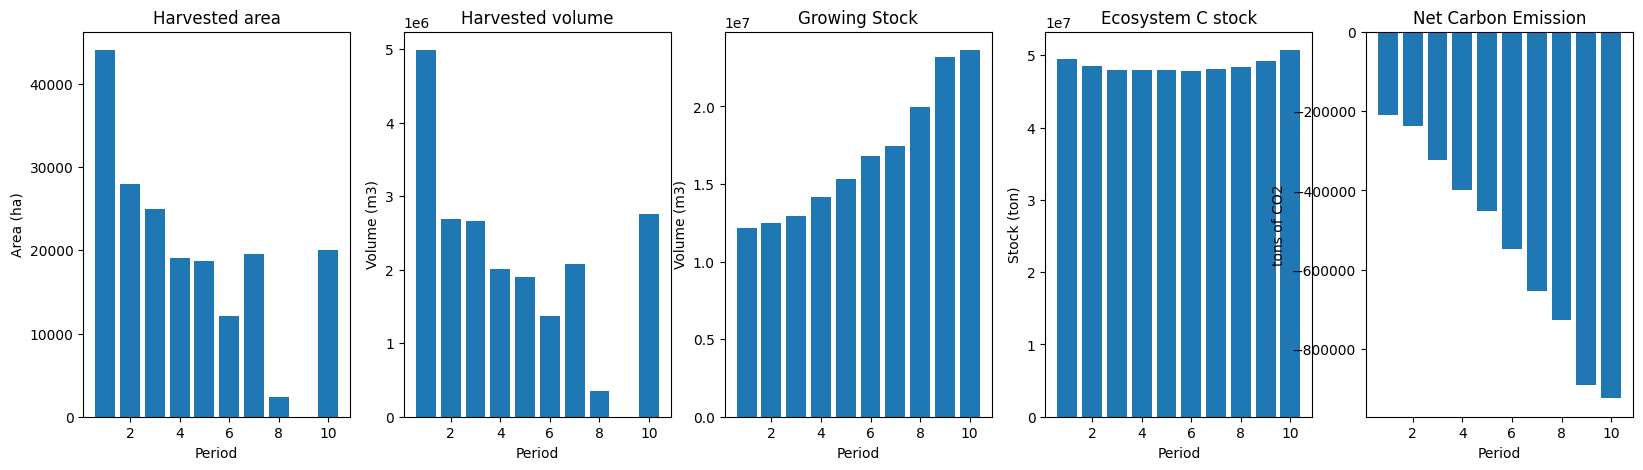

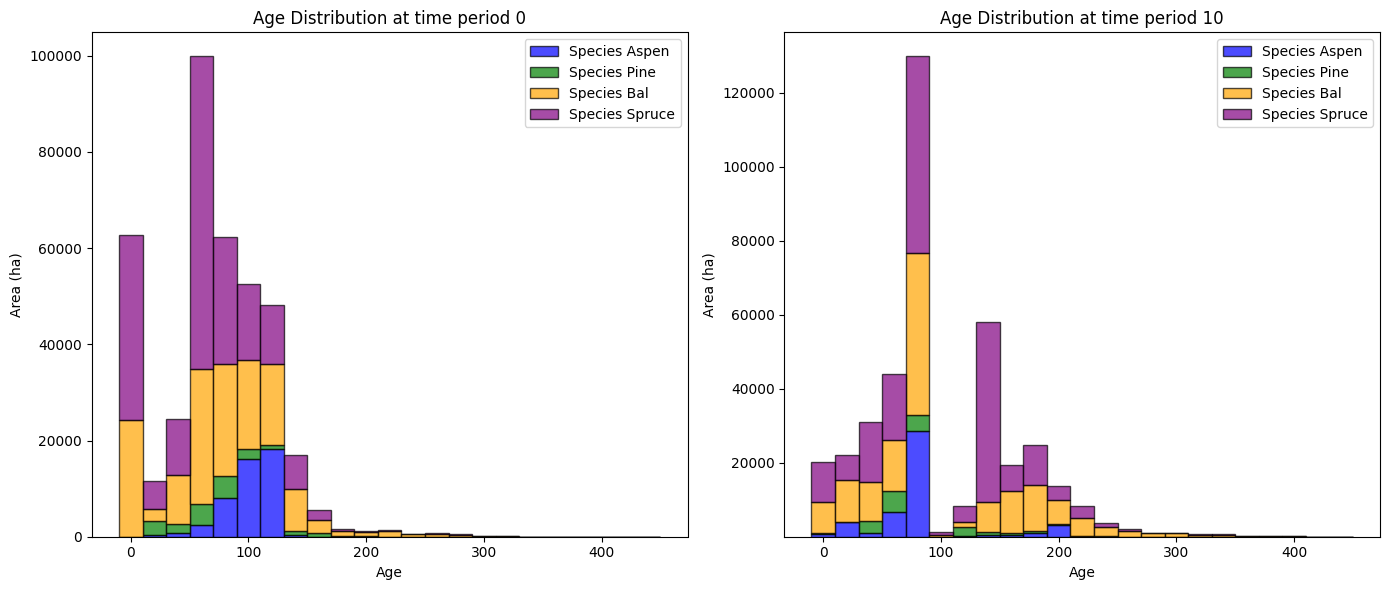

Plot saved to ./outputs/fig/redchris/redchris_min_em_no_cons_age_distribution.pdf

Old Growth (older than 100 years old) Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                   0            10    Difference
Aspen   34645.917062   5240.525650 -29405.391412
Pine     4625.490357   5196.732822    571.242465
Bal     51617.066583  51977.635700    360.569117
Spruce  38702.562785  81586.448705  42883.885921

Overall diversity has **increased** by 14410.31 hectares from time period 0 to time period 10.


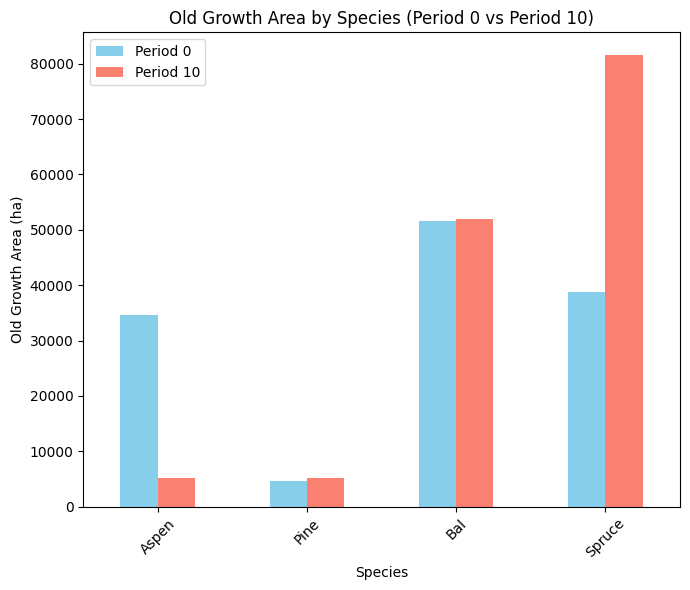

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_no_cons_old_growth_comparison.pdf

Portion for time period 0:
Aspen: 0.2198
Pine: 0.0581
Bal: 0.4123
Spruce: 0.3099

Portion for time period 10:
Aspen: 0.0857
Pine: 0.0493
Bal: 0.4285
Spruce: 0.4365

Shannon Evennes Index for time period 0: 0.8848
Shannon Evennes Index for time period 10: 0.7818

Diversity has **increased** by 10.30% from time 0 to time 10.


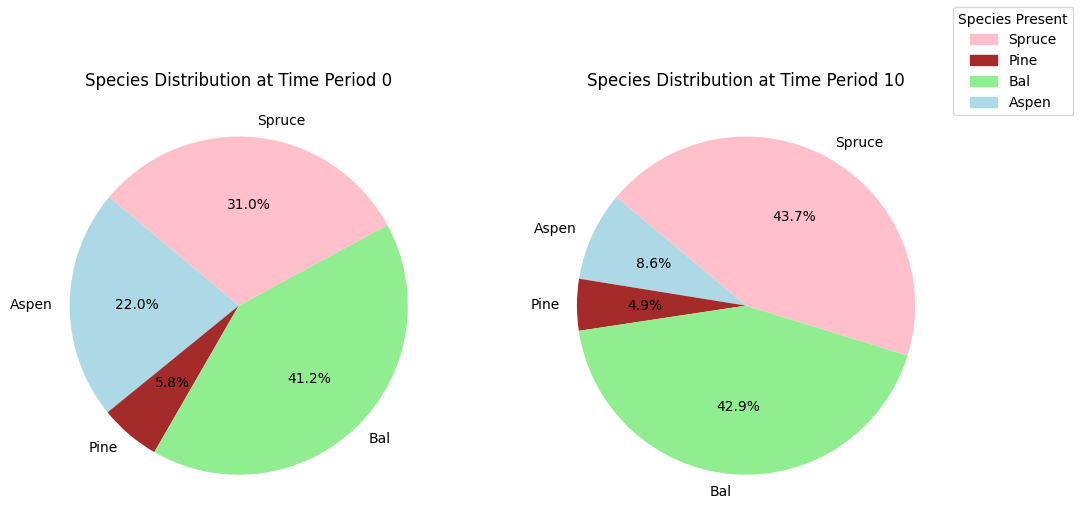

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_no_cons_species_pie.pdf
running business as usual scenario for the Red Chris mining site,
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3709 rows, 34533 columns and 459071 nonzeros
Model fingerprint: 0x3264d71d
Coefficient statistics:
  Matrix range     [1e-02, 1e+06]
  Objective range  [9e-02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+06]
Presolve removed 2010 rows and 2005 columns
Presolve time: 0.11s
Presolved: 1699 rows, 32528 columns, 422291 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 6.066e+04
 Factor NZ  : 8.155e+04 (roughly 14 MB of memory)
 Factor Ops : 

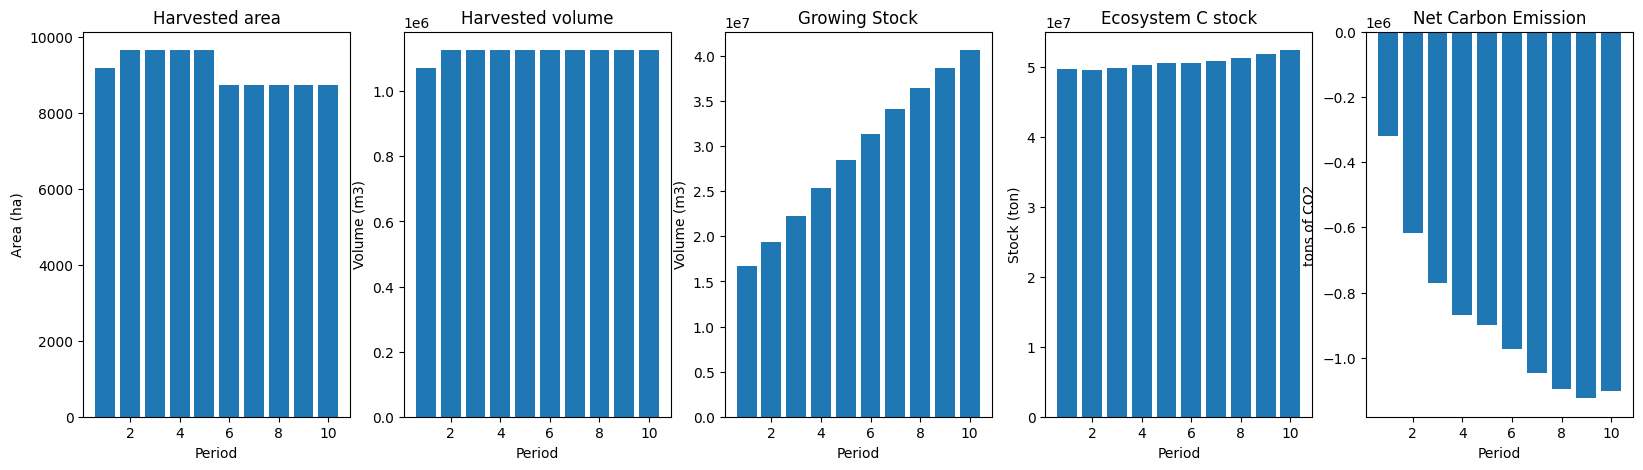

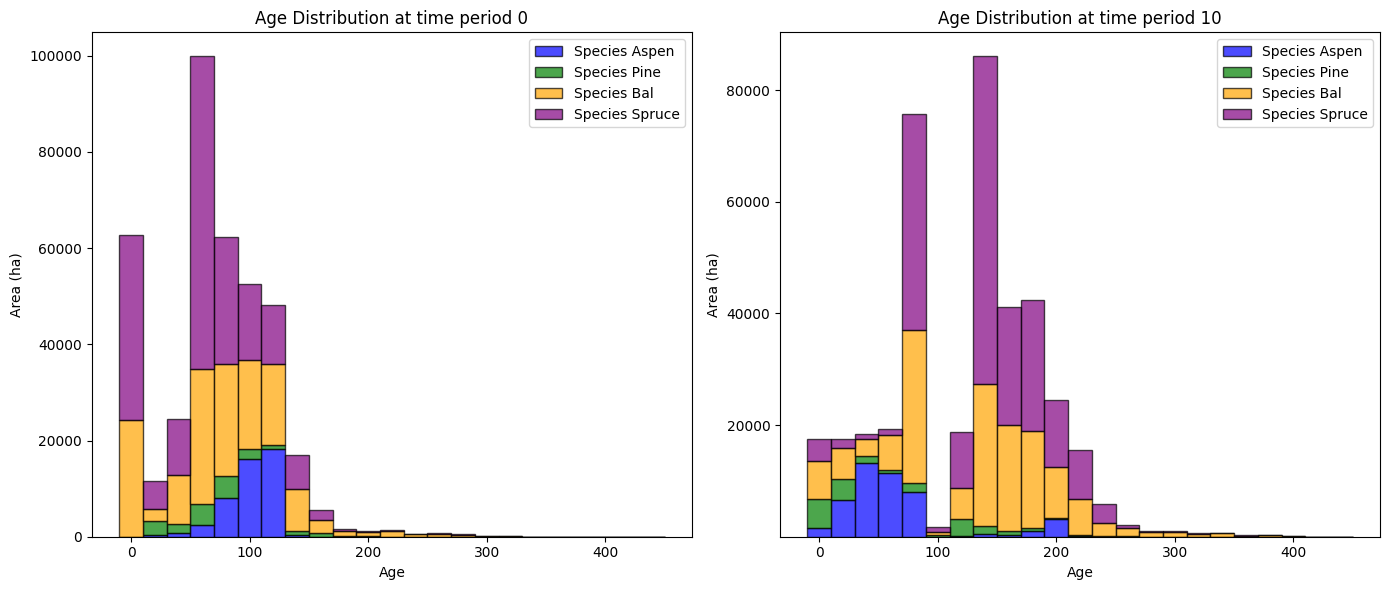

Plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_age_distribution.pdf

Old Growth (older than 100 years old) Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                   0             10     Difference
Aspen   34645.917062    5240.525650  -29405.391412
Pine     4625.490357    6571.108562    1945.618205
Bal     51617.066583   90700.396221   39083.329638
Spruce  38702.562785  139792.892568  101090.329784

Overall diversity has **increased** by 112713.89 hectares from time period 0 to time period 10.


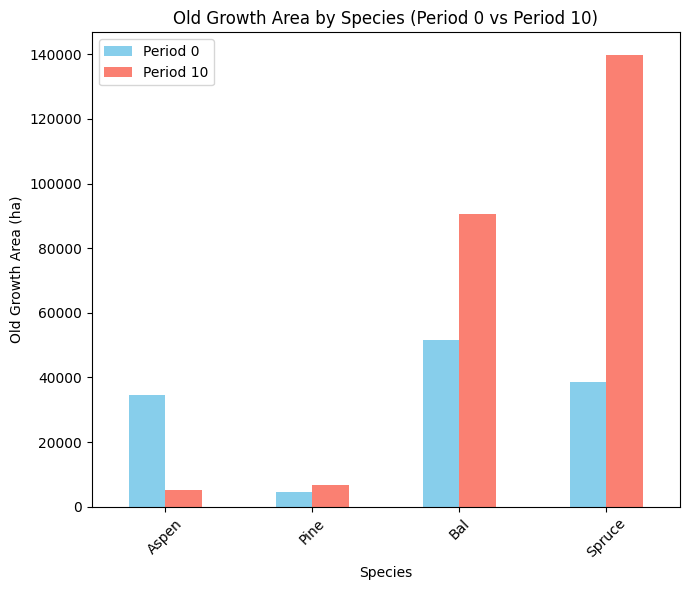

Clustered column plot saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_old_growth_comparison.pdf

Portion for time period 0:
Aspen: 0.2198
Pine: 0.0581
Bal: 0.4123
Spruce: 0.3099

Portion for time period 10:
Aspen: 0.0287
Pine: 0.0255
Bal: 0.4090
Spruce: 0.5368

Shannon Evennes Index for time period 0: 0.8848
Shannon Evennes Index for time period 10: 0.6457

Diversity has **increased** by 23.92% from time 0 to time 10.


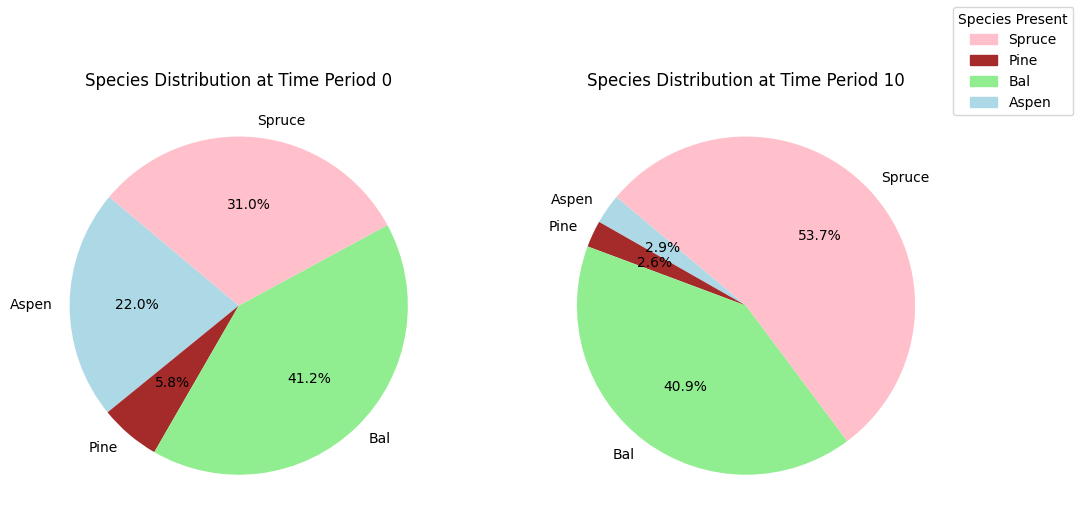

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/redchris/redchris_min_em_bau_redchrs_species_pie.pdf


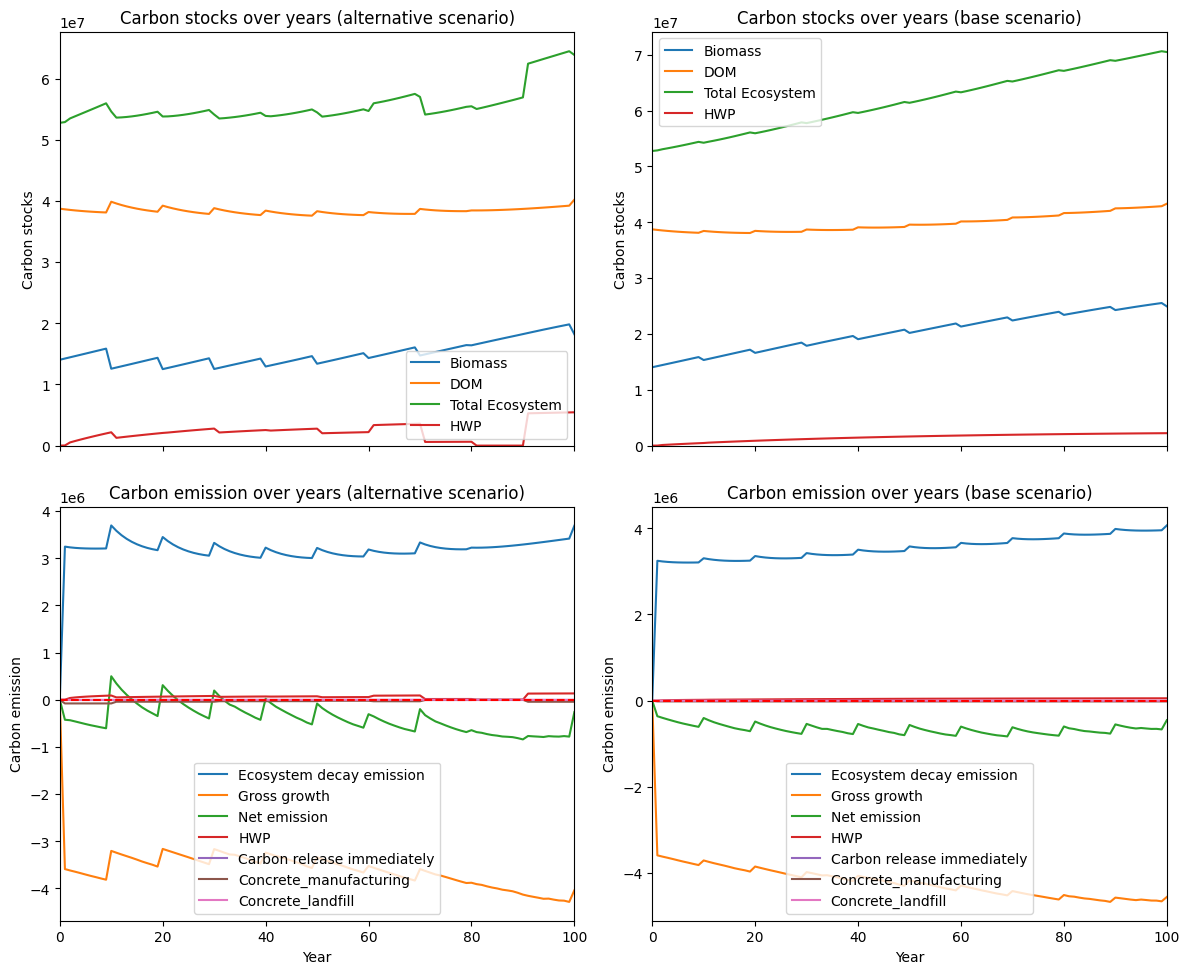

Net emission difference 9009911.089571204
Net emission base scenario -4074630.7292345767
Net emission alternative scenario -13084541.818805782
dollar_per_ton is:  1.109888865781906
It took 5.4 minutes to run this script.


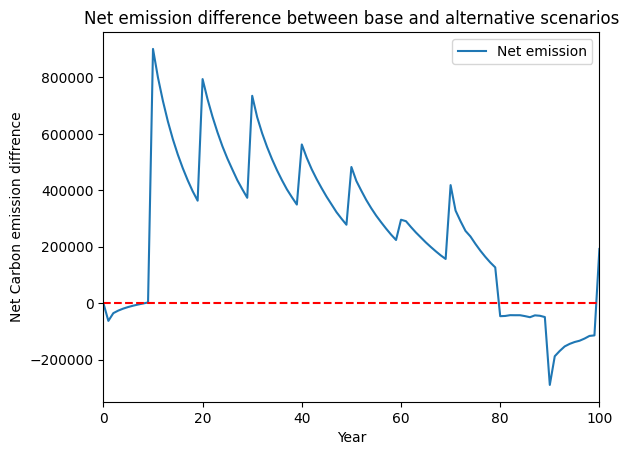

In [44]:
Start = time.time()

results_scenarios(fm, 
                  clt_percentage, 
                  credibility, 
                  budget_input, 
                  n_steps, 
                  max_harvest, 
                  scenario_name, 
                  displacement_effect, 
                  hwp_pool_effect_value, 
                  release_immediately_value, 
                  case_study, 
                  obj_mode,                   
                  pickle_output_base=False, 
                  pickle_output_alter=False)

print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

In [47]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 5.5 minutes to run this script.
